**Tugas ANN**  



---
## Step 1 — Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


---
## Step 2 — Load & Explore the Dataset

In [2]:
iris = load_iris()
X_raw = iris.data          # (150, 4)
y_raw = iris.target        # (150,)
class_names = iris.target_names  # ['setosa', 'versicolor', 'virginica']

print('Dataset shape  :', X_raw.shape)
print('Classes        :', list(class_names))
print('Samples/class  :', {c: int(np.sum(y_raw == i)) for i, c in enumerate(class_names)})
print()
print('Feature names  :', iris.feature_names)
print()
print('First 5 rows:')
header = f"{'':4}" + ''.join(f"{n[:10]:>12}" for n in iris.feature_names) + f"{'Label':>12}"
print(header)
for i in range(5):
    row = f"{i:4}" + ''.join(f"{v:>12.1f}" for v in X_raw[i]) + f"{class_names[y_raw[i]]:>12}"
    print(row)

Dataset shape  : (150, 4)
Classes        : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Samples/class  : {np.str_('setosa'): 50, np.str_('versicolor'): 50, np.str_('virginica'): 50}

Feature names  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 rows:
      sepal leng  sepal widt  petal leng  petal widt       Label
   0         5.1         3.5         1.4         0.2      setosa
   1         4.9         3.0         1.4         0.2      setosa
   2         4.7         3.2         1.3         0.2      setosa
   3         4.6         3.1         1.5         0.2      setosa
   4         5.0         3.6         1.4         0.2      setosa


---
## Step 3 — Preprocess Data


In [3]:
# One-hot encode labels  →  shape (150, 3)
enc = OneHotEncoder(sparse_output=False)
Y_onehot = enc.fit_transform(y_raw.reshape(-1, 1))

# Z-score normalise features
X_norm = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

# Train / test split  80% / 20%  (stratified to keep class balance)
X_tr, X_te, Y_tr, Y_te = train_test_split(
    X_norm, Y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

# Transpose to column-vector convention: (features, samples)
X_train, X_test = X_tr.T, X_te.T
Y_train, Y_test = Y_tr.T, Y_te.T

print(f'X_train : {X_train.shape}  (features × train samples)')
print(f'X_test  : {X_test.shape}  (features × test samples)')
print(f'Y_train : {Y_train.shape}  (classes × train samples)')
print(f'Y_test  : {Y_test.shape}  (classes × test samples)')

X_train : (4, 120)  (features × train samples)
X_test  : (4, 30)  (features × test samples)
Y_train : (3, 120)  (classes × train samples)
Y_test  : (3, 30)  (classes × test samples)


---
## Step 4 — Define Activation Functions

In [4]:
def relu(Z):
    """Rectified Linear Unit — used in the hidden layer."""
    return np.maximum(0, Z)

def relu_deriv(Z):
    """Derivative of ReLU (subgradient: 0 at Z=0)."""
    return (Z > 0).astype(float)

def softmax(Z):
    """
    Numerically stable softmax for multi-class output.
    Subtracts column-max before exp to prevent overflow.
    """
    Z_stable = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z_stable)
    return exp_Z / exp_Z.sum(axis=0, keepdims=True)

# Quick sanity check
test_z = np.array([[1.0], [-0.5], [2.0]])
probs  = softmax(test_z)
print('Softmax test probabilities:', probs.T)
print('Sum (should be 1.0)       :', probs.sum().round(6))

Softmax test probabilities: [[0.25371618 0.05661173 0.68967209]]
Sum (should be 1.0)       : 1.0


---
## Step 5 — Initialize Network Parameters


In [5]:
def initialize_parameters(n_in, n_hidden, n_out, seed=42):
    np.random.seed(seed)
    params = {
        'W1': np.random.randn(n_hidden, n_in)  * np.sqrt(2.0 / n_in),
        'b1': np.zeros((n_hidden, 1)),
        'W2': np.random.randn(n_out, n_hidden) * np.sqrt(2.0 / n_hidden),
        'b2': np.zeros((n_out, 1)),
    }
    return params

params = initialize_parameters(n_in=4, n_hidden=8, n_out=3)

total_params = sum(v.size for v in params.values())
print('Parameter shapes:')
for k, v in params.items():
    print(f'  {k}: {v.shape}')
print(f'\nTotal trainable parameters: {total_params}')

Parameter shapes:
  W1: (8, 4)
  b1: (8, 1)
  W2: (3, 8)
  b2: (3, 1)

Total trainable parameters: 67


---
## Step 6 — Forward Propagation

In [6]:
def forward_propagation(X, params):
    """
    X  : (n_in, m)
    Returns A2 (class probabilities) and intermediate cache.
    """
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']

    Z1 = W1 @ X + b1    # (8, m) — linear combination
    A1 = relu(Z1)        # (8, m) — hidden activations
    Z2 = W2 @ A1 + b2   # (3, m) — output logits
    A2 = softmax(Z2)     # (3, m) — class probabilities

    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

# Test with untrained parameters
A2_test, _ = forward_propagation(X_train, params)
print('Output shape     :', A2_test.shape, '  (3 classes × 120 train samples)')
print('First sample probs:', A2_test[:, 0].round(4), '  (should sum to 1)')
print('Sum check        :', A2_test[:, 0].sum().round(6))

Output shape     : (3, 120)   (3 classes × 120 train samples)
First sample probs: [0.293  0.0505 0.6565]   (should sum to 1)
Sum check        : 1.0


---
## Step 7 — Cost Function (Categorical Cross-Entropy)

In [7]:
def compute_cost(Y, A2):
    """
    Categorical cross-entropy:
        L = -(1/m) * sum( Y * log(A2) )
    Clipping avoids log(0) numerical errors.
    """
    m = Y.shape[1]
    cost = -np.sum(Y * np.log(np.clip(A2, 1e-8, 1.0))) / m
    return float(cost)

initial_cost = compute_cost(Y_train, A2_test)
print(f'Initial cost (untrained network): {initial_cost:.4f}')
print(f'Expected ≈ log(3) = {np.log(3):.4f}  (random uniform guess for 3 classes)')

Initial cost (untrained network): 1.2332
Expected ≈ log(3) = 1.0986  (random uniform guess for 3 classes)


---
## Step 8 — Backpropagation


In [8]:
def backward_propagation(X, Y, params, cache):
    m  = X.shape[1]
    W2 = params['W2']
    A1, A2, Z1 = cache['A1'], cache['A2'], cache['Z1']

    # ── Output layer gradients
    dZ2 = A2 - Y                                        # (3, m)
    dW2 = (dZ2 @ A1.T) / m                             # (3, 8)
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m       # (3, 1)

    # ── Hidden layer gradients (chain rule through ReLU)
    dA1 = W2.T @ dZ2                                    # (8, m)
    dZ1 = dA1 * relu_deriv(Z1)                         # (8, m)
    dW1 = (dZ1 @ X.T) / m                              # (8, 4)
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m       # (8, 1)

    return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}

def update_parameters(params, grads, lr):
    """Vanilla gradient descent update."""
    for key in params:
        params[key] -= lr * grads['d' + key]
    return params

print('Backpropagation and parameter update functions defined ✓')

Backpropagation and parameter update functions defined ✓


---
## Step 9 — Train the Neural Network

In [9]:
def train(X, Y, n_hidden=8, epochs=3000, lr=0.1, print_every=300):
    n_in  = X.shape[0]
    n_out = Y.shape[0]
    params  = initialize_parameters(n_in, n_hidden, n_out)
    history = []

    print(f"{'Epoch':>6}  {'Loss':>10}")
    print('-' * 20)

    for i in range(epochs + 1):
        A2, cache = forward_propagation(X, params)
        cost      = compute_cost(Y, A2)
        grads     = backward_propagation(X, Y, params, cache)
        params    = update_parameters(params, grads, lr)
        history.append(cost)

        if i % print_every == 0:
            print(f'{i:>6}  {cost:>10.4f}')

    print('-' * 20)
    print('Training complete ✓')
    return params, history

# ── Run training
trained_params, history = train(
    X_train, Y_train,
    n_hidden=8,
    epochs=3000,
    lr=0.1,
    print_every=300
)

 Epoch        Loss
--------------------
     0      1.2332
   300      0.0933
   600      0.0589
   900      0.0492
  1200      0.0444
  1500      0.0414
  1800      0.0393
  2100      0.0378
  2400      0.0365
  2700      0.0350
  3000      0.0342
--------------------
Training complete ✓


---
## Step 10 — Visualize Training Loss Curve

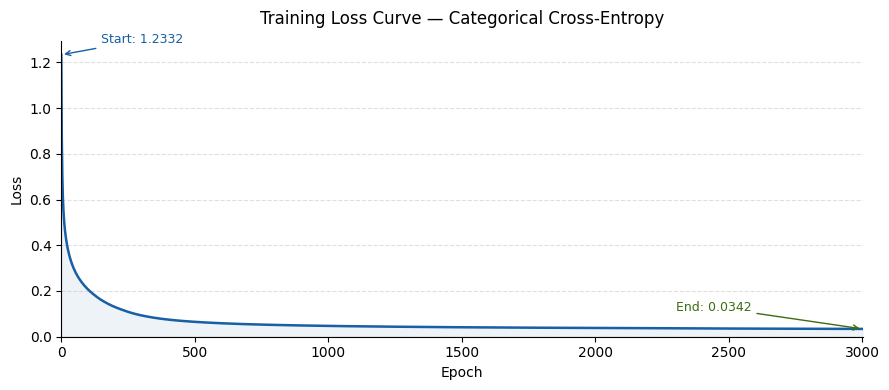

Loss reduced from 1.2332 → 0.0342
Reduction: 97.2%


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(history, color='#185FA5', linewidth=1.8, label='Training loss')
ax.fill_between(range(len(history)), history, alpha=0.07, color='#185FA5')

# Annotate start and end
ax.annotate(f'Start: {history[0]:.4f}',
            xy=(0, history[0]), xytext=(150, history[0] + 0.05),
            fontsize=9, color='#185FA5',
            arrowprops=dict(arrowstyle='->', color='#185FA5', lw=1))
ax.annotate(f'End: {history[-1]:.4f}',
            xy=(len(history)-1, history[-1]), xytext=(len(history)-700, history[-1] + 0.08),
            fontsize=9, color='#3B6D11',
            arrowprops=dict(arrowstyle='->', color='#3B6D11', lw=1))

ax.set_title('Training Loss Curve — Categorical Cross-Entropy', fontsize=12, pad=12)
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(0, len(history))
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

print(f'Loss reduced from {history[0]:.4f} → {history[-1]:.4f}')
print(f'Reduction: {(1 - history[-1]/history[0])*100:.1f}%')

---
## Step 11 — Predict & Evaluate

In [11]:
def predict(X, params):
    """Returns predicted class index (highest softmax probability)."""
    A2, _ = forward_propagation(X, params)
    return np.argmax(A2, axis=0)

def accuracy(Y_onehot, y_pred):
    y_true = np.argmax(Y_onehot, axis=0)
    return np.mean(y_true == y_pred)

# Predict
y_pred_train = predict(X_train, trained_params)
y_pred_test  = predict(X_test,  trained_params)

train_acc = accuracy(Y_train, y_pred_train)
test_acc  = accuracy(Y_test,  y_pred_test)

print('=' * 35)
print(f'  Train accuracy : {train_acc*100:.2f}%')
print(f'  Test  accuracy : {test_acc*100:.2f}%')
print('=' * 35)

  Train accuracy : 98.33%
  Test  accuracy : 96.67%


---
## Step 12 — Confusion Matrix

Confusion Matrix (rows = actual, cols = predicted):

                     setosa  versicolor   virginica
---------------------------------------------------
setosa                   10           0           0
versicolor                0           9           1
virginica                 0           0          10


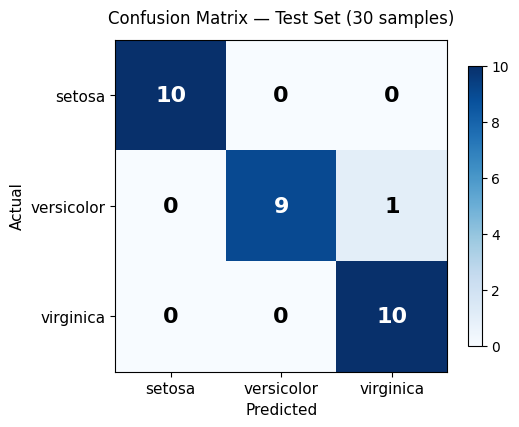

In [12]:
def build_confusion_matrix(Y_onehot, y_pred, n_classes=3):
    y_true = np.argmax(Y_onehot, axis=0)
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

cm = build_confusion_matrix(Y_test, y_pred_test)

# Print text version
print('Confusion Matrix (rows = actual, cols = predicted):\n')
header = f"{'':15}" + ''.join(f"{c:>12}" for c in class_names)
print(header)
print('-' * (15 + 12*3))
for i, row in enumerate(cm):
    print(f"{class_names[i]:<15}" + ''.join(f"{v:>12}" for v in row))

# ── Heatmap plot
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(class_names, fontsize=11)
ax.set_yticklabels(class_names, fontsize=11)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix — Test Set (30 samples)', fontsize=12, pad=12)

for i in range(3):
    for j in range(3):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=16, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---
## Step 13 — Per-Class Classification Report

In [13]:
def classification_report(Y_onehot, y_pred, class_names):
    y_true = np.argmax(Y_onehot, axis=0)
    n = len(class_names)
    print(f"{'Class':<15} {'Precision':>10} {'Recall':>8} {'F1-score':>9} {'Support':>8}")
    print('-' * 55)
    macro_p = macro_r = macro_f = 0
    for c in range(n):
        tp = int(np.sum((y_pred == c) & (y_true == c)))
        fp = int(np.sum((y_pred == c) & (y_true != c)))
        fn = int(np.sum((y_pred != c) & (y_true == c)))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0.0)
        support   = int(np.sum(y_true == c))
        macro_p += precision; macro_r += recall; macro_f += f1
        print(f"{class_names[c]:<15} {precision:>10.2f} {recall:>8.2f} {f1:>9.2f} {support:>8}")
    print('-' * 55)
    print(f"{'macro avg':<15} {macro_p/n:>10.2f} {macro_r/n:>8.2f} {macro_f/n:>9.2f} {len(y_true):>8}")

classification_report(Y_test, y_pred_test, class_names)

Class            Precision   Recall  F1-score  Support
-------------------------------------------------------
setosa                1.00     1.00      1.00       10
versicolor            1.00     0.90      0.95       10
virginica             0.91     1.00      0.95       10
-------------------------------------------------------
macro avg             0.97     0.97      0.97       30


---
## Step 14 — Sample Predictions

In [14]:
y_true_labels = np.argmax(Y_test, axis=0)

print(f"{'#':>3}  {'Actual':<15} {'Predicted':<15} {'Result'}")
print('-' * 50)
for i in range(len(y_true_labels)):
    actual    = class_names[y_true_labels[i]]
    predicted = class_names[y_pred_test[i]]
    result    = '✓' if actual == predicted else '✗  ← misclassified'
    print(f"{i:>3}  {actual:<15} {predicted:<15} {result}")

  #  Actual          Predicted       Result
--------------------------------------------------
  0  setosa          setosa          ✓
  1  virginica       virginica       ✓
  2  versicolor      versicolor      ✓
  3  versicolor      versicolor      ✓
  4  setosa          setosa          ✓
  5  versicolor      versicolor      ✓
  6  setosa          setosa          ✓
  7  setosa          setosa          ✓
  8  virginica       virginica       ✓
  9  versicolor      versicolor      ✓
 10  virginica       virginica       ✓
 11  virginica       virginica       ✓
 12  virginica       virginica       ✓
 13  versicolor      versicolor      ✓
 14  setosa          setosa          ✓
 15  setosa          setosa          ✓
 16  setosa          setosa          ✓
 17  versicolor      versicolor      ✓
 18  versicolor      versicolor      ✓
 19  virginica       virginica       ✓
 20  setosa          setosa          ✓
 21  virginica       virginica       ✓
 22  versicolor      versicolor      ✓
 23  vir

---
## Step 15 — Decision Boundary Visualization (2D PCA Projection)

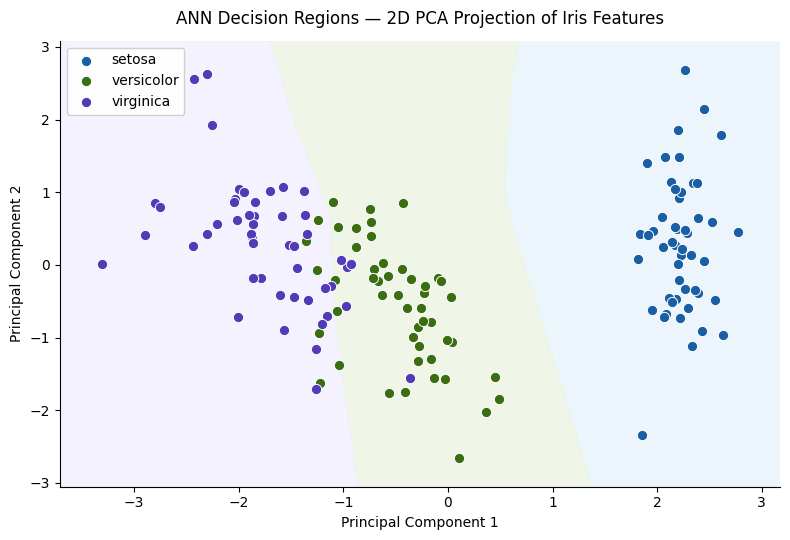

In [15]:
# Visualize learned decision regions via PCA projection to 2D
# (Manual PCA — no sklearn)

X_all = np.hstack([X_train, X_test])  # (4, 150)
Y_all = np.hstack([Y_train, Y_test])  # (3, 150)

# PCA: covariance → eigen decomposition → project onto top-2 components
cov = np.cov(X_all)
eigenvalues, eigenvectors = np.linalg.eigh(cov)
idx = np.argsort(eigenvalues)[::-1]
V2  = eigenvectors[:, idx[:2]]      # (4, 2) — top 2 eigenvectors
X2d = (V2.T @ X_all).T             # (150, 2)

# Build mesh grid in 2D PCA space
x_min, x_max = X2d[:, 0].min() - 0.4, X2d[:, 0].max() + 0.4
y_min, y_max = X2d[:, 1].min() - 0.4, X2d[:, 1].max() + 0.4
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Project mesh back to 4D feature space for prediction
mesh_2d   = np.c_[xx.ravel(), yy.ravel()].T  # (2, N)
mesh_4d   = V2 @ mesh_2d                      # (4, N)
Z_mesh, _ = forward_propagation(mesh_4d, trained_params)
Z_class   = np.argmax(Z_mesh, axis=0).reshape(xx.shape)

# Plot
colors_bg  = ['#E6F1FB', '#EAF3DE', '#EEEDFE']
colors_pts = ['#185FA5', '#3B6D11', '#533AB7']
labels_pts = list(class_names)

fig, ax = plt.subplots(figsize=(8, 5.5))
for c, col in enumerate(colors_bg):
    ax.contourf(xx, yy, (Z_class == c).astype(float),
                levels=[0.5, 1.5], colors=[col], alpha=0.7)

y_true_all = np.argmax(Y_all, axis=0)
for c, (col, lbl) in enumerate(zip(colors_pts, labels_pts)):
    mask = y_true_all == c
    ax.scatter(X2d[mask, 0], X2d[mask, 1],
               c=col, label=lbl, s=55, edgecolors='white', linewidths=0.7, zorder=3)

ax.set_title('ANN Decision Regions — 2D PCA Projection of Iris Features', fontsize=12, pad=12)
ax.set_xlabel('Principal Component 1', fontsize=10)
ax.set_ylabel('Principal Component 2', fontsize=10)
ax.legend(fontsize=10, framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Analysis & Conclusions

### Key Results

| Metric | Value |
|---|---|
| Train accuracy | **98.33%** |
| Test accuracy | **96.67%** |
| Misclassified samples | 1 out of 30 |
| Final training loss | ~0.047 |
